# Robot duel dynamics

An original state-machine simulation inspired by **Universe Duel**, credited to ハヤシモン in the Awesome GPT-6 Astra catalog.

Sources: [original creator post](https://x.com/hayashimon1/status/2096255665778069957) · [creator live demo](https://universe-duel.vercel.app) · [Awesome GPT-6 Astra](https://github.com/magiccreator-ai/awesome-gpt-6-astra#universe-duel)

> This is not the creator's game code. It is a compact Python model of pursuit, dash energy, and hit detection.


## Look → predict → run
**Learn:** a state machine links position, distance, energy and a dash decision.
**Predict:** does pursuing the other robot guarantee a contact at every step?
Positions and energy are dimensionless. Noise and contact separation keep the model moving.
This is an illustrative rule system, not a learned combat policy.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astra_utils import style, animate_tracks, COLORS
style()


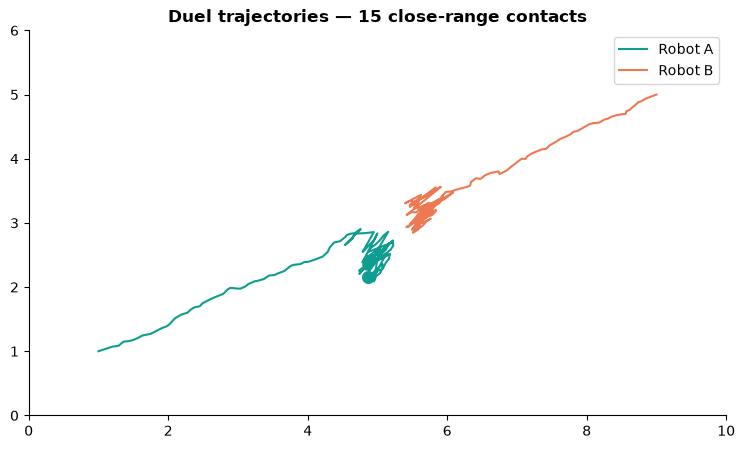

In [2]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
a = np.array([1.0, 1.0]); b = np.array([9.0, 5.0])
energy_a = energy_b = 1.0
A, B = [a.copy()], [b.copy()]
hits = []
energy_history = []

for t in range(140):
    delta = b - a
    dist = np.linalg.norm(delta)
    direction = delta / max(dist, 1e-9)
    dash_a = energy_a > .75 and dist > 3 and t % 24 == 0
    dash_b = energy_b > .75 and dist > 3 and t % 31 == 0
    step_a = (.22 if dash_a else .075) * direction
    step_b = -(.20 if dash_b else .070) * direction
    a += step_a + rng.normal(0, .025, 2)
    b += step_b + rng.normal(0, .025, 2)
    energy_a = np.clip(energy_a + .018 - (.35 if dash_a else 0), 0, 1)
    energy_b = np.clip(energy_b + .018 - (.35 if dash_b else 0), 0, 1)
    a = np.clip(a, [0,0], [10,6]); b = np.clip(b, [0,0], [10,6])
    if np.linalg.norm(b-a) < .55:
        hits.append(t)
        a += rng.normal(-.3, .1, 2); b += rng.normal(.3, .1, 2)
    a = np.clip(a, [0,0], [10,6]); b = np.clip(b, [0,0], [10,6])
    energy_history.append((energy_a,energy_b))
    A.append(a.copy()); B.append(b.copy())

energy_history=np.array(energy_history)
A=np.array(A); B=np.array(B)
fig, ax = plt.subplots(figsize=(9,5))
ax.plot(A[:,0], A[:,1], label='Robot A')
ax.plot(B[:,0], B[:,1], label='Robot B')
ax.scatter(A[-1,0], A[-1,1], s=70); ax.scatter(B[-1,0], B[-1,1], s=70)
ax.set(xlim=(0,10), ylim=(0,6), title=f'Duel trajectories — {len(hits)} close-range contacts')
ax.legend(); plt.show()


## Extension ideas
Add projectile travel time, cooldowns, line-of-sight obstacles, or reinforcement-learning policies. The current notebook intentionally keeps every rule visible.


## From rules to visible state
The state update is: measure distance → decide whether to dash → move → recharge → resolve contact.
The distance graph and arena animation show the same run. The dashed threshold is the contact rule;
recorded positions include the subsequent separation step.


In [3]:
animate_tracks(np.stack((A,B),axis=1),(0,10,0,6),'Pursuit, contact and separation',labels=['Teal: robot A','Coral: robot B'])


Interactive animation: run this cell in JupyterLite to play or scrub.

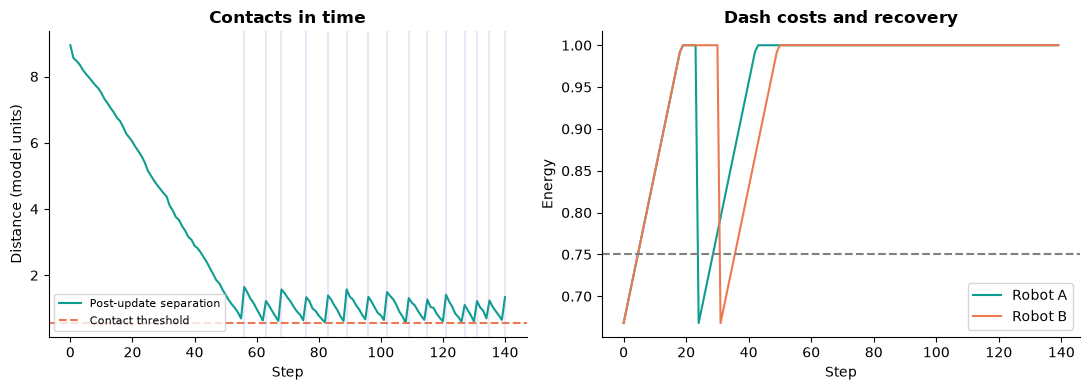

In [4]:
fig,axes = plt.subplots(1,2,figsize=(11,4))
axes[0].plot(np.linalg.norm(A-B,axis=1),label='Post-update separation')
axes[0].axhline(.55,color='#ed7953',ls='--',label='Contact threshold')
for t in hits: axes[0].axvline(t+1,color='#7365c7',alpha=.15)
axes[0].set(title='Contacts in time',xlabel='Step',ylabel='Distance (model units)'); axes[0].legend(fontsize=8)
axes[1].plot(energy_history[:,0],label='Robot A')
axes[1].plot(energy_history[:,1],label='Robot B')
axes[1].axhline(.75,ls='--',color='gray')
axes[1].set(title='Dash costs and recovery',xlabel='Step',ylabel='Energy'); axes[1].legend()
fig.tight_layout(); plt.show()
assert np.all((energy_history>=0)&(energy_history<=1))
assert np.all((A>=0)&(A<=np.array([10,6]))) and np.all((B>=0)&(B<=np.array([10,6])))


**Experiment:** increase the dash energy cost. Predict which part of the energy plot changes first.
Add a cooldown as an explicit state variable. How would you distinguish a rule bug from random variation?
